<a href="https://colab.research.google.com/github/garlich/Data/blob/main/2_R_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Step 2: R Analysis**
### Chicago Crime & Weather Analysis

- Test the 5 dimensions from Step 1a
- Covering: overall correlation, outdoor/indoor, per crime type, COVID, lag features, day of the week and seasonality

Using R runtime in Colab. Using CSV that loads from GitHub repo, `chicago_crime_weather_2017_2024.csv`, (output from 1_Explore_Clean.ipynb)

In [1]:
# install corrplot for heatmaps
install.packages('corrplot', quiet = TRUE)
library(corrplot)
cat('Ready :)\n')

corrplot 0.95 loaded



Ready :)


In [2]:
# load the CSV from GitHub
df <- read.csv('https://raw.githubusercontent.com/garlich/Data/main/chicago_crime_weather_2017_2024.csv')
df$crime_date <- as.Date(df$crime_date)
cat('Shape:', nrow(df), 'rows x', ncol(df), 'cols\n')
head(df, 5)

Shape: 2920 rows x 38 cols


,crime_date,day_of_week,month,year,day_of_year,is_weekend,is_holiday,total_crimes,total_arrests,domestic_crimes,⋯,visibility_miles,wind_speed_knots,max_wind_speed_knots,gust_speed_knots,precipitation_in,snow_depth_in,fog,rain_drizzle,snow_ice_pellets,thunder
,<date>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<int>
1,2017-01-01,1,1,2017,1,1,1,1281,168,416,⋯,9.5,4.5,11.1,15.9,0.00,NA,0,0,0,0
2,2017-01-02,2,1,2017,2,0,0,613,110,131,⋯,7.2,5.2,8.0,NA,0.00,NA,0,1,0,0
3,2017-01-03,3,1,2017,3,0,0,721,133,137,⋯,2.4,5.9,18.1,22.9,0.11,NA,1,1,0,0
4,2017-01-04,4,1,2017,4,0,0,614,108,116,⋯,9.7,14.9,18.1,28.0,0.00,NA,0,0,0,0
5,2017-01-05,5,1,2017,5,0,0,612,115,111,⋯,9.9,11.5,17.1,19.0,0.00,NA,0,0,1,0


In [3]:
# quick summary of target + main weather inputs
summary(df[, c('total_crimes', 'outdoor_count', 'indoor_count',
               'mean_temp_f', 'precipitation_in', 'wind_speed_knots')])

  total_crimes    outdoor_count    indoor_count     mean_temp_f    
 Min.   :  36.0   Min.   : 14.0   Min.   :  18.0   Min.   :-15.00  
 1st Qu.: 613.0   1st Qu.:217.0   1st Qu.: 285.0   1st Qu.: 37.00  
 Median : 687.0   Median :255.0   Median : 310.0   Median : 52.70  
 Mean   : 679.3   Mean   :257.2   Mean   : 312.0   Mean   : 52.57  
 3rd Qu.: 750.2   3rd Qu.:296.0   3rd Qu.: 333.2   3rd Qu.: 70.33  
 Max.   :1901.0   Max.   :503.0   Max.   :1081.0   Max.   : 90.20  
 precipitation_in wind_speed_knots
 Min.   :0.0000   Min.   : 1.70   
 1st Qu.:0.0000   1st Qu.: 6.10   
 Median :0.0000   Median : 7.90   
 Mean   :0.1099   Mean   : 8.31   
 3rd Qu.:0.0600   3rd Qu.:10.20   
 Max.   :3.7400   Max.   :23.80   

# **Part A: Overall correlations**

In [4]:
# A1: correlation of each weather var with total_crimes
weather_cols <- c('mean_temp_f', 'min_temp_f', 'max_temp_f', 'dew_point_f',
                  'sea_level_pressure', 'visibility_miles', 'wind_speed_knots',
                  'precipitation_in')

cor_with_crime <- sapply(weather_cols, function(col) cor(df[[col]], df$total_crimes))
cor_with_crime <- sort(cor_with_crime, decreasing = TRUE)
print(round(cor_with_crime, 3))

       mean_temp_f         max_temp_f         min_temp_f        dew_point_f 
             0.459              0.448              0.445              0.439 
  visibility_miles   precipitation_in sea_level_pressure   wind_speed_knots 
             0.151              0.005             -0.132             -0.148 


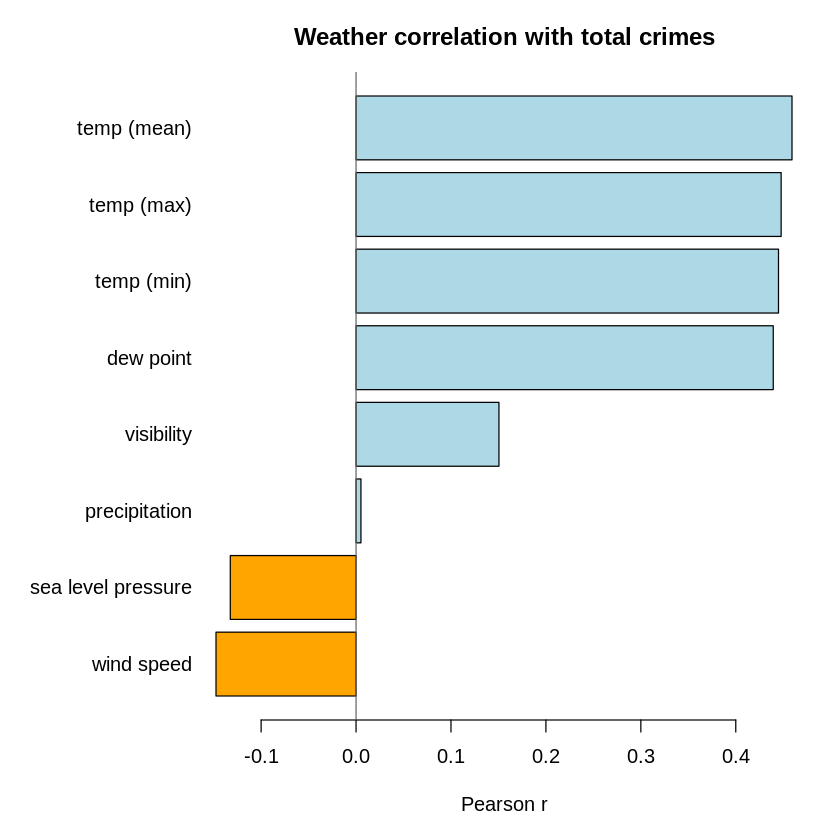

In [15]:
# A2: bar plot
par(mar = c(5, 9, 3, 2))
labels_pretty <- c(
  mean_temp_f = 'temp (mean)', min_temp_f = 'temp (min)', max_temp_f = 'temp (max)',
  dew_point_f = 'dew point', sea_level_pressure = 'sea level pressure',
  visibility_miles = 'visibility', wind_speed_knots = 'wind speed',
  precipitation_in = 'precipitation'
)
bar_cols <- ifelse(cor_with_crime > 0, 'lightblue', 'orange')
barplot(rev(cor_with_crime), horiz = TRUE, las = 1, col = rev(bar_cols),
        names.arg = rev(labels_pretty[names(cor_with_crime)]),
        main = 'Weather correlation with total crimes', xlab = 'Pearson r')
abline(v = 0, col = 'gray40')

Temperature variables (mean, max, min, dew point) correlate strongly positive at 0.44-0.46. Visibility weakly positive (0.15). Precipitation effectively zero. Wind speed and sea level pressure both slightly negative (-0.13 to -0.15).

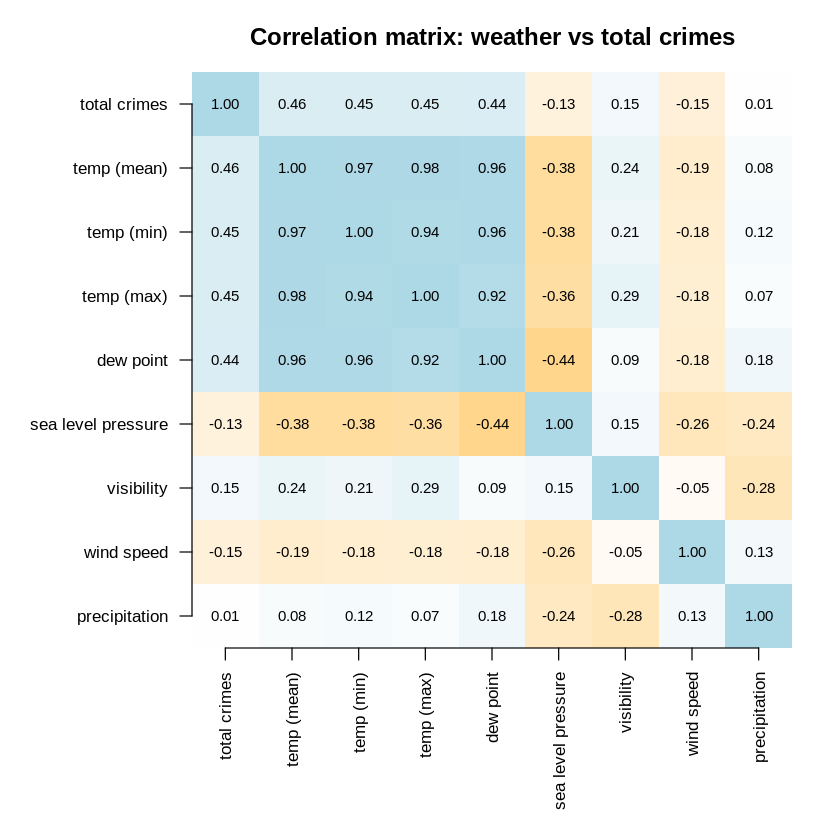

In [16]:
# A3: correlation matrix
df_for_plot <- df[, c('total_crimes', weather_cols)]
colnames(df_for_plot) <- c('total crimes',
                            'temp (mean)', 'temp (min)', 'temp (max)', 'dew point',
                            'sea level pressure', 'visibility', 'wind speed',
                            'precipitation')
cor_matrix <- cor(df_for_plot)

# base R heatmap
n <- ncol(cor_matrix)
par(mar = c(8, 8, 3, 2))
image(1:n, 1:n, t(cor_matrix[n:1, ]),
      col = colorRampPalette(c('orange', 'white', 'lightblue'))(200),
      zlim = c(-1, 1), axes = FALSE,
      xlab = '', ylab = '',
      main = 'Correlation matrix: weather vs total crimes')

axis(1, at = 1:n, labels = colnames(cor_matrix), las = 2, cex.axis = 0.85)
axis(2, at = 1:n, labels = rev(rownames(cor_matrix)), las = 1, cex.axis = 0.85)

# adding the correlation values on top
for (i in 1:n) for (j in 1:n) {
  text(j, n - i + 1, sprintf('%.2f', cor_matrix[i, j]), cex = 0.75)
}

# **Part B: Dimension 1, outdoor vs indoor**

In [17]:
# B1: correlations side by side
outdoor_cors <- sapply(weather_cols, function(col) cor(df[[col]], df$outdoor_count))
indoor_cors  <- sapply(weather_cols, function(col) cor(df[[col]], df$indoor_count))

compare <- data.frame(
  variable = weather_cols,
  outdoor  = round(outdoor_cors, 3),
  indoor   = round(indoor_cors, 3),
  diff     = round(outdoor_cors - indoor_cors, 3),
  row.names = NULL
)
print(compare[order(-abs(compare$diff)), ])

            variable outdoor indoor   diff
1        mean_temp_f   0.625  0.215  0.410
3         max_temp_f   0.613  0.209  0.404
2         min_temp_f   0.605  0.219  0.386
4        dew_point_f   0.576  0.208  0.368
7   wind_speed_knots  -0.216 -0.066 -0.150
6   visibility_miles   0.234  0.088  0.146
5 sea_level_pressure  -0.163 -0.091 -0.072
8   precipitation_in  -0.037 -0.011 -0.026


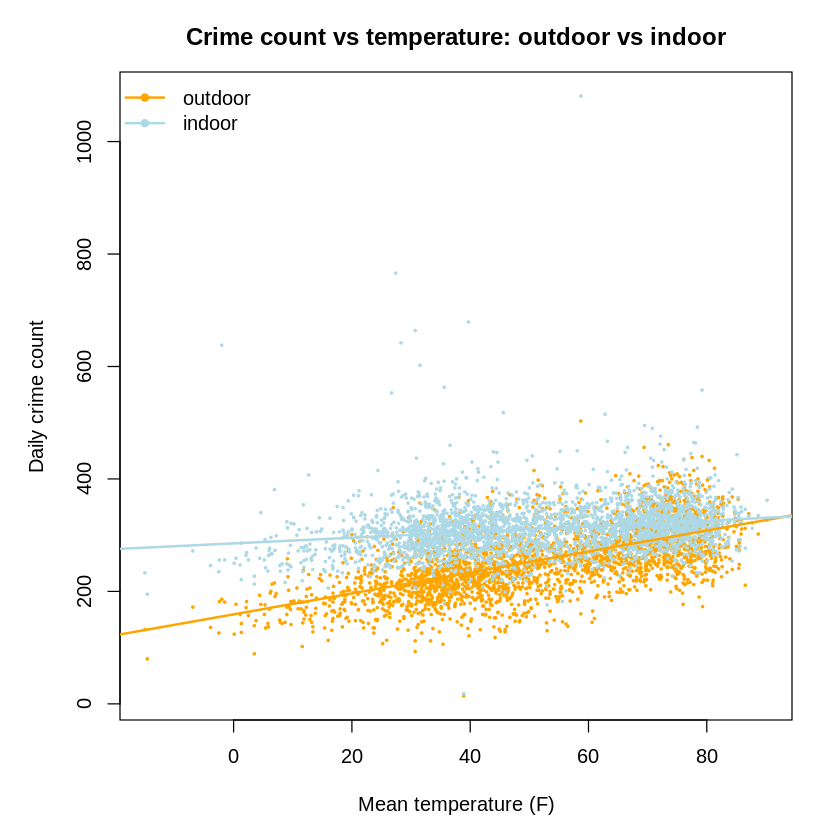

In [19]:
# B2: outdoor vs indoor against temperature
par(mar = c(5, 5, 3, 2))
plot(df$mean_temp_f, df$outdoor_count, col = 'orange', pch = 20, cex = 0.4,
     xlab = 'Mean temperature (F)', ylab = 'Daily crime count',
     main = 'Crime count vs temperature: outdoor vs indoor',
     ylim = range(c(df$outdoor_count, df$indoor_count)))
points(df$mean_temp_f, df$indoor_count, col = 'lightblue', pch = 20, cex = 0.4)
abline(lm(outdoor_count ~ mean_temp_f, data = df), col = 'orange',    lwd = 2)
abline(lm(indoor_count  ~ mean_temp_f, data = df), col = 'lightblue', lwd = 2)
legend('topleft', c('outdoor', 'indoor'), col = c('orange', 'lightblue'),
       pch = 20, lwd = 2, bty = 'n')

Outdoor steeper than indoor. Could be that weather works through exposure/opportunity (more people outside on warm days) but without mood effect, otherwise indoor crime would rise too.

# **Part C: Dimension 2, crime type sensitivity**

In [20]:
# C1: correlation per crime type vs weather
crime_cols <- c('total_crimes', 'theft_count', 'battery_count', 'damage_count',
                'assault_count', 'burglary_count', 'robbery_count',
                'narcotics_count', 'motor_theft_count', 'domestic_crimes')

weather_short <- c('mean_temp_f', 'precipitation_in', 'wind_speed_knots', 'visibility_miles')

cor_sub <- cor(df[, c(crime_cols, weather_short)])[crime_cols, weather_short]
print(round(cor_sub, 3))

                  mean_temp_f precipitation_in wind_speed_knots
total_crimes            0.459            0.005           -0.148
theft_count             0.337            0.026           -0.120
battery_count           0.492            0.005           -0.124
damage_count            0.495            0.010           -0.128
assault_count           0.562            0.018           -0.143
burglary_count          0.106            0.012           -0.015
robbery_count           0.159           -0.008           -0.105
narcotics_count        -0.091            0.037            0.025
motor_theft_count       0.099           -0.061           -0.049
domestic_crimes         0.402            0.012           -0.099
                  visibility_miles
total_crimes                 0.151
theft_count                  0.096
battery_count                0.168
damage_count                 0.163
assault_count                0.183
burglary_count               0.016
robbery_count                0.046
narcotics_count 

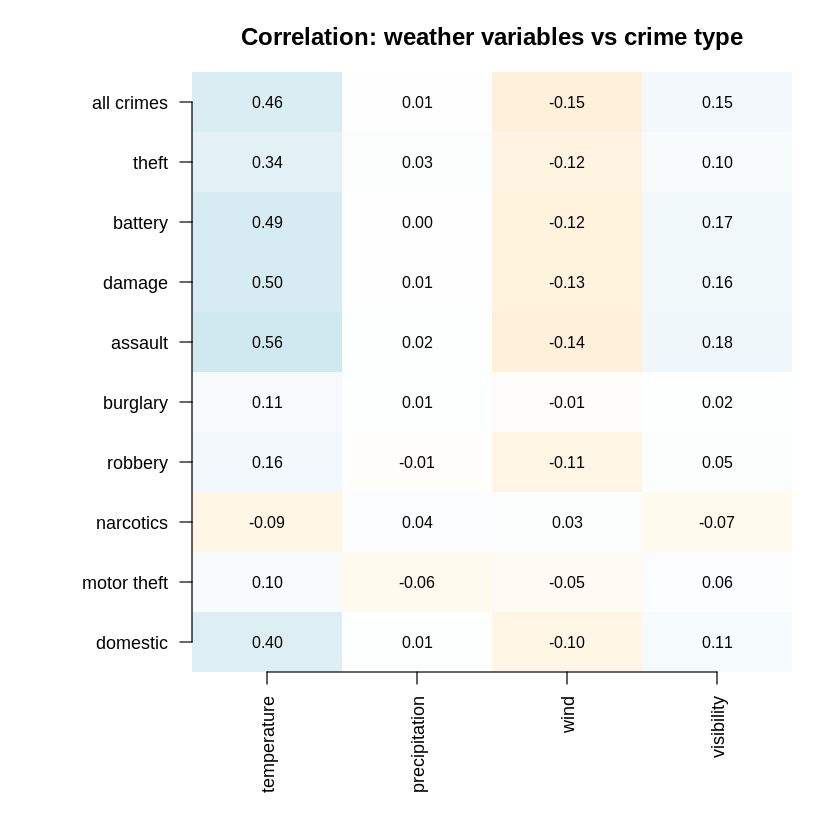

In [21]:
# C2: heatmap
cor_for_plot <- cor_sub
rownames(cor_for_plot) <- c('all crimes', 'theft', 'battery', 'damage',
                             'assault', 'burglary', 'robbery',
                             'narcotics', 'motor theft', 'domestic')
colnames(cor_for_plot) <- c('temperature', 'precipitation', 'wind', 'visibility')

nr <- nrow(cor_for_plot); nc <- ncol(cor_for_plot)
par(mar = c(7, 8, 3, 2))
image(1:nc, 1:nr, t(cor_for_plot[nr:1, ]),
      col = colorRampPalette(c('orange', 'white', 'lightblue'))(200),
      zlim = c(-1, 1), axes = FALSE,
      xlab = '', ylab = '',
      main = 'Correlation: weather variables vs crime type')

axis(1, at = 1:nc, labels = colnames(cor_for_plot), las = 2, cex.axis = 0.9)
axis(2, at = 1:nr, labels = rev(rownames(cor_for_plot)), las = 1, cex.axis = 0.9)

for (i in 1:nr) for (j in 1:nc) {
  text(j, nr - i + 1, sprintf('%.2f', cor_for_plot[i, j]), cex = 0.8)
}

- Assault (0.56), damage (0.50), battery (0.49): strongest positive temp correlations. Outdoor, interpersonal.
- Domestic (0.40): high, may reflect that domestic incidents include outdoor public confrontations not just home incidents.
- Theft (0.34): moderate positive. Mixed indoor/outdoor settings.
- Robbery (0.16), burglary (0.11), motor theft (0.10): weak positive, much less weather-sensitive.
- Narcotics (-0.09): only negative correlation, weather doesn't slow this category

# **Part D: Dimension 3, COVID**

In [22]:
# D1: split into 3 periods and compute correlations per period
df$period <- ifelse(df$year <= 2019, 'pre_covid',
              ifelse(df$year <= 2021, 'covid', 'post_covid'))
df$period <- factor(df$period, levels = c('pre_covid', 'covid', 'post_covid'))

period_stats <- do.call(rbind, lapply(levels(df$period), function(p) {
  g <- df[df$period == p, ]
  data.frame(
    period       = p,
    n_days       = nrow(g),
    mean_crimes  = round(mean(g$total_crimes), 0),
    cor_temp     = round(cor(g$mean_temp_f,      g$total_crimes), 3),
    cor_precip   = round(cor(g$precipitation_in, g$total_crimes), 3),
    cor_wind     = round(cor(g$wind_speed_knots, g$total_crimes), 3)
  )
}))
print(period_stats, row.names = FALSE)

     period n_days mean_crimes cor_temp cor_precip cor_wind
  pre_covid   1095         731    0.672      0.013   -0.204
      covid    729         578    0.359     -0.073   -0.105
 post_covid   1096         695    0.641     -0.021   -0.244


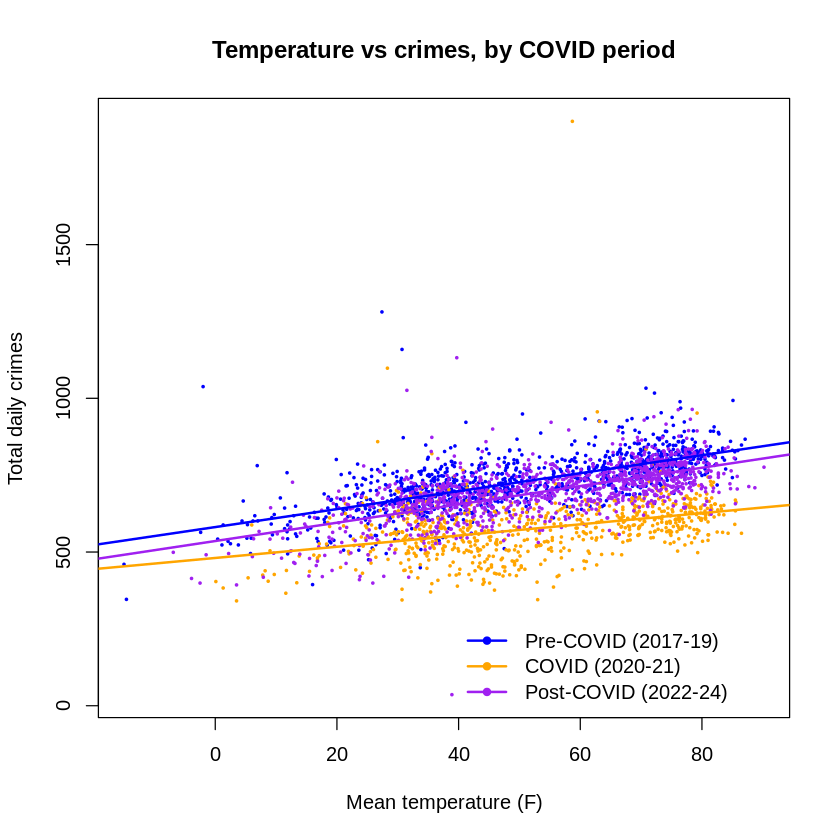

In [27]:
# D2: plot per period
period_labels <- c(pre_covid = 'Pre-COVID (2017-19)',
                   covid     = 'COVID (2020-21)',
                   post_covid = 'Post-COVID (2022-24)')
period_colours <- c(pre_covid = 'blue', covid = 'orange', post_covid = 'purple')

plot(df$mean_temp_f, df$total_crimes,
     col = period_colours[as.character(df$period)], pch = 20, cex = 0.4,
     xlab = 'Mean temperature (F)', ylab = 'Total daily crimes',
     main = 'Temperature vs crimes, by COVID period')

for (p in levels(df$period)) {
  g <- df[df$period == p, ]
  abline(lm(total_crimes ~ mean_temp_f, data = g), col = period_colours[p], lwd = 2)
}
legend('bottomright', legend = period_labels, col = period_colours,
       pch = 20, lwd = 2, bty = 'n')

COVID period: 21% fewer crimes per day on average (578 vs 731 pre-COVID). Temperature-crime correlation almost halved (0.36 vs 0.67 pre / 0.64 post).

Keeping these years in training

# **Part E: Dimension 4, cumulative weather effects**

Does today's temperature predict today's crime, or does the past week's average predict it better? checking the cumulative effect to see if for example a hot week matters more than a single hot day

In [28]:
# E1: build features and compare correlations
df <- df[order(df$crime_date), ]
n <- nrow(df)

df$temp_yesterday   <- c(NA, head(df$mean_temp_f, -1))
df$temp_3_days_ago  <- c(rep(NA, 3), head(df$mean_temp_f, -3))

df$temp_3_day_avg <- NA_real_
df$temp_7_day_avg <- NA_real_
for (i in 3:n) df$temp_3_day_avg[i] <- mean(df$mean_temp_f[(i-2):i])
for (i in 7:n) df$temp_7_day_avg[i] <- mean(df$mean_temp_f[(i-6):i])

lag_cors <- c(
  temp_today      = cor(df$mean_temp_f,      df$total_crimes, use = 'complete.obs'),
  temp_yesterday  = cor(df$temp_yesterday,   df$total_crimes, use = 'complete.obs'),
  temp_3_days_ago = cor(df$temp_3_days_ago,  df$total_crimes, use = 'complete.obs'),
  temp_3_day_avg  = cor(df$temp_3_day_avg,   df$total_crimes, use = 'complete.obs'),
  temp_7_day_avg  = cor(df$temp_7_day_avg,   df$total_crimes, use = 'complete.obs')
)
print(round(lag_cors, 3))

     temp_today  temp_yesterday temp_3_days_ago  temp_3_day_avg  temp_7_day_avg 
          0.459           0.438           0.414           0.453           0.441 


Same-day temperature (0.459) correlates strongest, slightly ahead of rolling averages (0.45 / 0.44) and lagged values (0.44 / 0.41).

No cumulative effect to exploit here. Sticking with `mean_temp_f` (today only) for modelling

# **Part F: Dimension 5, day of week**

In [29]:
# F1: mean + sd per day
# day_of_week in CSV: 1=Sunday, 7=Saturday (BigQuery convention)
dow_labels <- c('Sun','Mon','Tue','Wed','Thu','Fri','Sat')
df$dow_name <- factor(dow_labels[df$day_of_week], levels = dow_labels)

dow_summary <- data.frame(
  day         = dow_labels,
  mean_crimes = round(tapply(df$total_crimes, df$dow_name, mean), 0),
  sd_crimes   = round(tapply(df$total_crimes, df$dow_name, sd),   0),
  row.names   = NULL
)
print(dow_summary)

  day mean_crimes sd_crimes
1 Sun         674       128
2 Mon         679       105
3 Tue         667       106
4 Wed         674        99
5 Thu         666       101
6 Fri         703       105
7 Sat         691       109


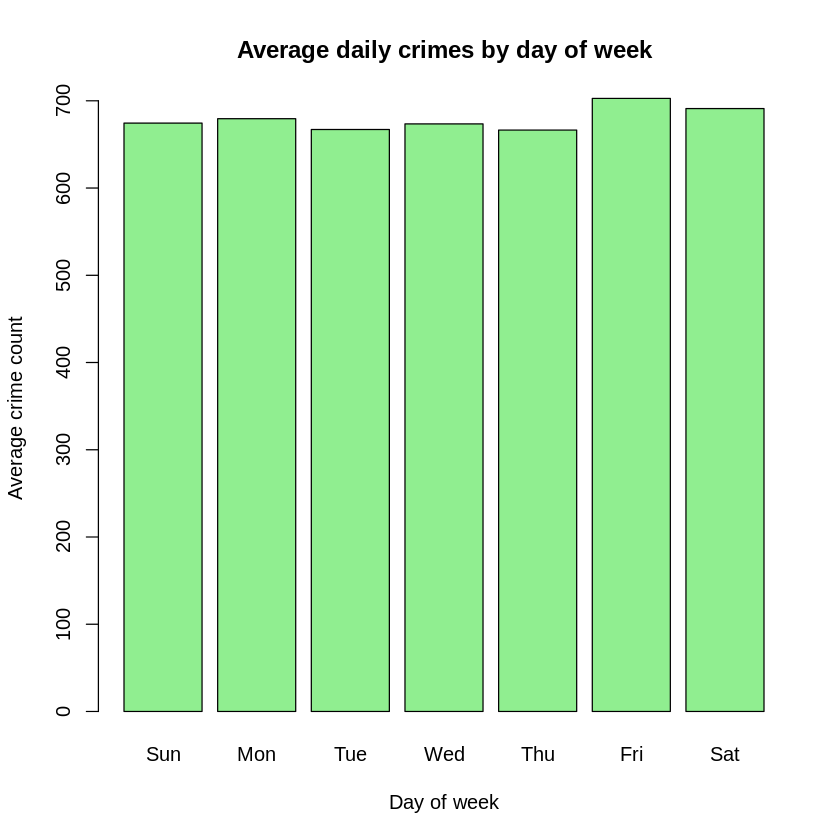

In [33]:
# F2: bar chart of average crime per day
dow_means <- tapply(df$total_crimes, df$dow_name, mean)
barplot(dow_means, col = 'lightgreen',
        main = 'Average daily crimes by day of week',
        xlab = 'Day of week', ylab = 'Average crime count')

In [34]:
# F3: ANOVA, is the day-of-week difference significant?
summary(aov(total_crimes ~ dow_name, data = df))

              Df   Sum Sq Mean Sq F value   Pr(>F)    
dow_name       6   441897   73650    6.31 1.32e-06 ***
Residuals   2913 34002526   11673                     
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

ANOVA tests whether the means of multiple groups (the 7 days of the week) are statistically different from each other. ANOVA F = 6.31, p = 1.3e-06 (well below 0.001). The day-of-week differences are statistically significant, not random noise. Day of week must be included as a feature in the models

# **Part G: Seasonality**

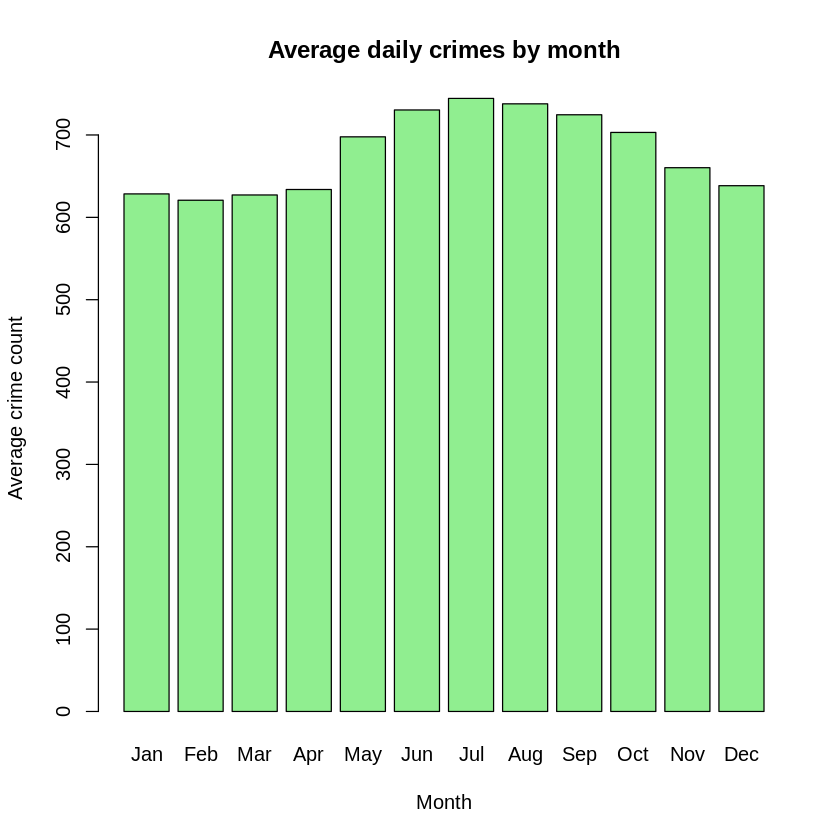

In [37]:
# G1: average daily crimes per month
month_labels <- c('Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec')
df$month_name <- factor(month_labels[df$month], levels = month_labels)

month_means <- tapply(df$total_crimes, df$month_name, mean)
barplot(month_means, col = 'lightgreen',
        main = 'Average daily crimes by month',
        xlab = 'Month', ylab = 'Average crime count')

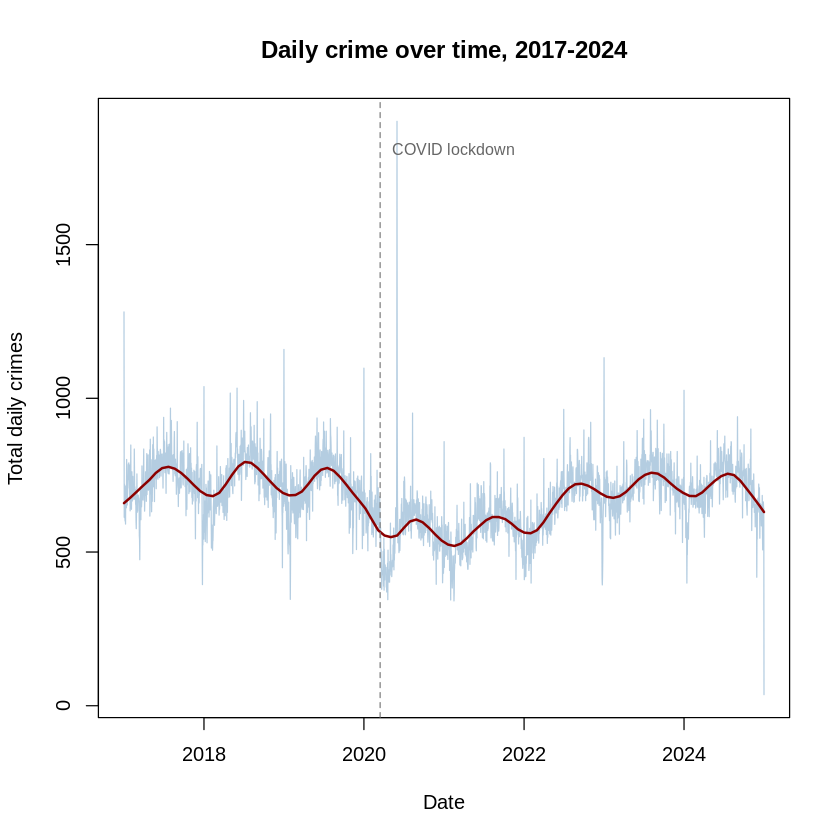

In [40]:
# G2:  time series with smoothed trend line (lowess)
# https://www.rdocumentation.org/packages/gplots/versions/3.3.0/topics/lowess

plot(df$crime_date, df$total_crimes, type = 'l', col = rgb(0.27, 0.51, 0.71, 0.4),
     xlab = 'Date', ylab = 'Total daily crimes',
     main = 'Daily crime over time, 2017-2024')
lines(lowess(df$crime_date, df$total_crimes, f = 0.08), col = 'darkred', lwd = 2)
abline(v = as.Date('2020-03-15'), col = 'gray50', lty = 2)
text(as.Date('2020-03-15'), max(df$total_crimes) * 0.95,
     'COVID lockdown', pos = 4, cex = 0.8, col = 'gray40')

# **Part H: Statistical models**

1. Simple linear regression (temperature only) as a baseline
2. Multiple linear regression with the features from dimensions 1-5
3. Poisson regression (count data, since crimes per day are counts) to compare

In [41]:
# H1: baseline linear regression, temperature only
m1 <- lm(total_crimes ~ mean_temp_f, data = df)
summary(m1)


Call:
lm(formula = total_crimes ~ mean_temp_f, data = df)

Residuals:
    Min      1Q  Median      3Q     Max 
-608.25  -59.05   15.26   59.25 1206.02 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) 544.57303    5.14340  105.88   <2e-16 ***
mean_temp_f   2.56238    0.09176   27.93   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 96.51 on 2918 degrees of freedom
Multiple R-squared:  0.2109,	Adjusted R-squared:  0.2106 
F-statistic: 779.9 on 1 and 2918 DF,  p-value: < 2.2e-16


In [42]:
# H2: multiple linear regression with features from the 5 dimensions
# temperature, precipitation, wind, day of week, month, covid period
m2 <- lm(total_crimes ~ mean_temp_f + precipitation_in + wind_speed_knots +
                        dow_name + month_name + period,
         data = df)
summary(m2)


Call:
lm(formula = total_crimes ~ mean_temp_f + precipitation_in + 
    wind_speed_knots + dow_name + month_name + period, data = df)

Residuals:
    Min      1Q  Median      3Q     Max 
-611.62  -37.14   -1.33   35.05 1316.29 

Coefficients:
                  Estimate Std. Error t value Pr(>|t|)    
(Intercept)       611.1815     7.8744  77.616  < 2e-16 ***
mean_temp_f         3.2352     0.1471  21.987  < 2e-16 ***
precipitation_in  -17.8825     4.5530  -3.928 8.78e-05 ***
wind_speed_knots   -1.7920     0.4528  -3.958 7.74e-05 ***
dow_nameMon         3.7142     4.8861   0.760  0.44722    
dow_nameTue        -9.4648     4.8904  -1.935  0.05304 .  
dow_nameWed        -2.9739     4.8930  -0.608  0.54338    
dow_nameThu        -8.3797     4.8892  -1.714  0.08665 .  
dow_nameFri        30.9232     4.8905   6.323 2.96e-10 ***
dow_nameSat        19.0814     4.8906   3.902 9.77e-05 ***
month_nameFeb     -18.8881     6.5225  -2.896  0.00381 ** 
month_nameMar     -42.0586     6.6364  -6.338 2.

R2 jumps to 0.58 from 0.21 in H1.

- Friday is +31 crimes/day vs Sunday baseline (Saturday +19). Other weekdays barely differ from Sunday
- COVID period is -161 crimes/day even after controlling for weather. Post-COVID -44 (volume still hasn't fully recovered)
- Temperature effect 3.2 crimes per degree F, slightly stronger once other variables are held constant
- Precipitation -17.9 crimes/inch, wind -1.8 crimes/knot, both negative

Most coefficients have p < 0.001

In [43]:
# H3: test whether adding the extra features significantly improves fit
# nested model ANOVA
anova(m1, m2)

,Res.Df,RSS,Df,Sum of Sq,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,2918,27180216,NA,NA,NA,NA
2,2897,14451080,21,12729137,121.5144,0


In [44]:
# H4: Poisson regression (model for count data)
# crimes per day are counts (non-negative integers), so a Poisson regression
# is the statistically correct model. Comparing it with the linear regression above
# https://www.dataquest.io/blog/tutorial-poisson-regression-in-r/

m3 <- glm(total_crimes ~ mean_temp_f + precipitation_in + wind_speed_knots +
                         dow_name + month_name + period,
          family = poisson, data = df)
summary(m3)


Call:
glm(formula = total_crimes ~ mean_temp_f + precipitation_in + 
    wind_speed_knots + dow_name + month_name + period, family = poisson, 
    data = df)

Coefficients:
                   Estimate Std. Error  z value Pr(>|z|)    
(Intercept)       6.412e+00  4.364e-03 1469.078  < 2e-16 ***
mean_temp_f       4.875e-03  8.117e-05   60.065  < 2e-16 ***
precipitation_in -2.521e-02  2.472e-03  -10.196  < 2e-16 ***
wind_speed_knots -2.710e-03  2.486e-04  -10.901  < 2e-16 ***
dow_nameMon       5.313e-03  2.659e-03    1.998   0.0457 *  
dow_nameTue      -1.437e-02  2.674e-03   -5.373 7.74e-08 ***
dow_nameWed      -4.535e-03  2.669e-03   -1.699   0.0892 .  
dow_nameThu      -1.268e-02  2.674e-03   -4.742 2.12e-06 ***
dow_nameFri       4.483e-02  2.639e-03   16.984  < 2e-16 ***
dow_nameSat       2.791e-02  2.650e-03   10.530  < 2e-16 ***
month_nameFeb    -3.103e-02  3.698e-03   -8.391  < 2e-16 ***
month_nameMar    -6.268e-02  3.734e-03  -16.784  < 2e-16 ***
month_nameApr    -1.002e-01  4.04

Same direction and significance as the linear model for every variable. Poisson coefficients are on the log scale so exp(coef) gives the multiplicative effect: for example exp(-0.246) aprox. 0.78 means COVID-period crime rates were about 78% of pre-COVID, aprox. 22% drop. This matches the linear regression finding

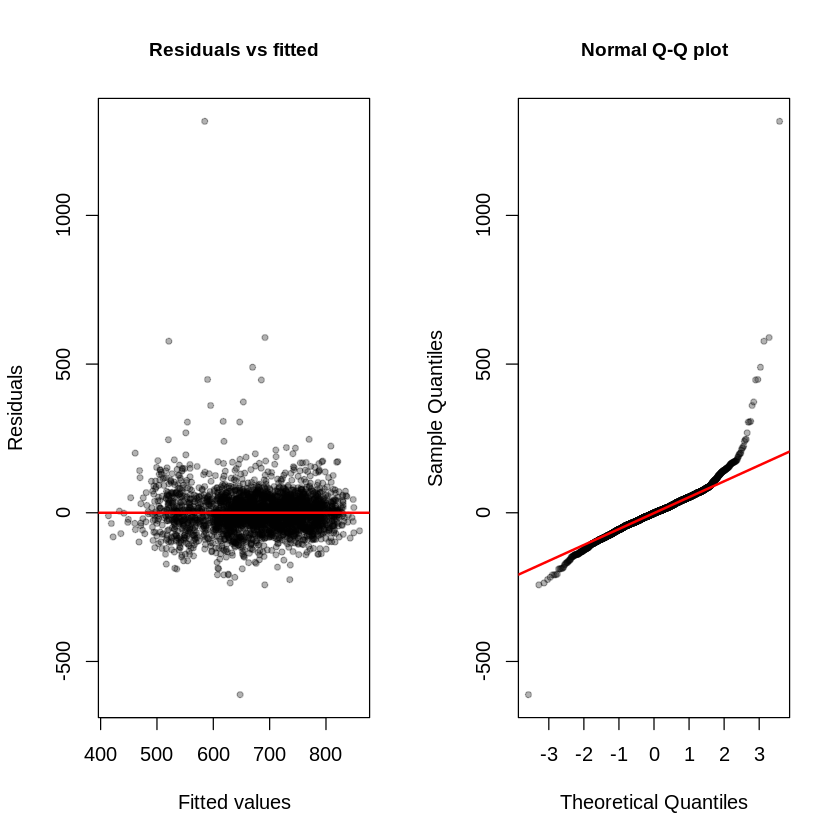

In [46]:
# H5: residual plot of the multiple linear regression
# normal Q-Q plot, checks if residuals follow a bell curve (the linear regression assumption)

par(mfrow = c(1, 2))
plot(fitted(m2), resid(m2), pch = 20, col = rgb(0,0,0,0.3),
     xlab = 'Fitted values', ylab = 'Residuals',
     main = 'Residuals vs fitted', cex.main = 0.95)
abline(h = 0, col = 'red', lwd = 2)

qqnorm(resid(m2), pch = 20, col = rgb(0,0,0,0.3), main = 'Normal Q-Q plot', cex.main = 0.95)
qqline(resid(m2), col = 'red', lwd = 2)
par(mfrow = c(1, 1))

Residuals cluster with no strong pattern, Q-Q plot mostly straight with some tails deviation (expected with count data). mostly with linear regression assumptions

In [47]:
# H6: significance tests on the key correlations
# quick cor.test on the main weather vs crime pairs for p-values + CIs
cat('mean_temp_f vs total_crimes:\n')
print(cor.test(df$mean_temp_f, df$total_crimes))

cat('\nprecipitation_in vs total_crimes:\n')
print(cor.test(df$precipitation_in, df$total_crimes))

cat('\noutdoor_count vs mean_temp_f:\n')
print(cor.test(df$outdoor_count, df$mean_temp_f))

cat('\nindoor_count vs mean_temp_f:\n')
print(cor.test(df$indoor_count, df$mean_temp_f))

mean_temp_f vs total_crimes:

	Pearson's product-moment correlation

data:  df$mean_temp_f and df$total_crimes
t = 27.926, df = 2918, p-value < 2.2e-16
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 0.4301262 0.4873892
sample estimates:
      cor 
0.4592347 


precipitation_in vs total_crimes:

	Pearson's product-moment correlation

data:  df$precipitation_in and df$total_crimes
t = 0.27853, df = 2918, p-value = 0.7806
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 -0.03112319  0.04142185
sample estimates:
        cor 
0.005156115 


outdoor_count vs mean_temp_f:

	Pearson's product-moment correlation

data:  df$outdoor_count and df$mean_temp_f
t = 43.271, df = 2918, p-value < 2.2e-16
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 0.6025791 0.6467932
sample estimates:
      cor 
0.6251875 


indoor_count vs mean_temp_f:

	Pearson's product-moment correl

Temperature correlations all significant (p < 2.2e-16). Precipitation with crime is not significant (p = 0.78). Outdoor temp correlation is approx. 3x stronger than indoor (0.63 vs 0.21)

# Summary

1. Outdoor vs indoor: outdoor crime tracks temperature much more strongly than indoor

2. Crime type: battery/assault/robbery highly temp-sensitive, burglary/domestic weather-invariant

3. COVID: temp/crime correlation weakens 2020-21

4. Cumulative weather: rolling temps don't beat same day. No cumulative effect to exploit, sticking with same day temp

5. Day of week: ANOVA significant. Fri highest, Sun lowest

6. Temperature variables >0.95 collinear, using `mean_temp_f` as the single representative